In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import bayesflow as bf

In [6]:
def simple_heston(
    lambda_=1.0,
    rho=-0.7,
    nu=0.2,
    theta=0.04,
    V0=0.04,
    T=1.0,
    n=100,
    N=1,
    S0=1.0
):
    """
    Simulate the simple (standard) Heston model via Euler-Maruyama.

    The model is:
        dS_t = S_t sqrt(V_t) dW_t
        dV_t = lambda*(theta - V_t)*dt + lambda*nu*sqrt(V_t)*dB_t
    where <dW_t, dB_t> = rho dt.

    Feller condition (2*lambda*theta >= (lambda*nu)^2) must hold; an
    AssertionError is raised if it is violated.

    Parameters
    ----------
    lambda_ : float - Mean-reversion speed.
    rho     : float - Correlation between price and variance Brownians.
    nu      : float - Vol-of-vol (normalized); must satisfy nu <= sqrt(2*theta/lambda_).
    theta   : float - Long-run variance.
    V0      : float - Initial variance.
    T       : float - Maturity in years.
    n       : int   - Time steps per year.
    N       : int   - Number of Monte Carlo paths.
    S0      : float - Initial asset price.

    Returns
    -------
    S : ndarray, shape (N, 1+s) - Asset price paths.
    V : ndarray, shape (N, 1+s) - Variance paths.
    """
    assert 2.0 * lambda_ * theta >= (lambda_ * nu) ** 2, (
        f"Feller condition violated: 2*lambda*theta={2*lambda_*theta:.4f} < "
        f"(lambda*nu)^2={(lambda_*nu)**2:.4f}."
    )

    s = int(n * T)
    dt = T / s
    sqrt_dt = np.sqrt(dt)

    dB = np.random.randn(N, s) * sqrt_dt
    dZ = np.random.randn(N, s) * sqrt_dt
    dW = rho * dB + np.sqrt(1.0 - rho**2) * dZ

    V_path = np.zeros((N, 1 + s))
    V_path[:, 0] = V0
    for i in range(s):
        V_prev = V_path[:, i]
        V_path[:, i + 1] = (V_prev
                            + lambda_ * (theta - V_prev) * dt
                            + lambda_ * nu * np.sqrt(np.maximum(V_prev, 0.0)) * dB[:, i])
        V_path[:, i + 1] = np.maximum(V_path[:, i + 1], 0.0)

    log_increments = -0.5 * V_path[:, :-1] * dt + np.sqrt(np.maximum(V_path[:, :-1], 0.0)) * dW
    log_S = np.zeros((N, 1 + s))
    log_S[:, 0] = np.log(S0)
    log_S[:, 1:] = np.log(S0) + np.cumsum(log_increments, axis=1)

    return {
        "price": np.exp(log_S).squeeze(),
        "volatility": V_path.squeeze(),
    }

In [7]:
sim = simple_heston()
sim["price"].shape

(101,)

In [8]:
def priors():
    lambda_ = np.random.gamma(2, 0.5)        # mean=1.0, positive
    theta   = np.random.gamma(2, 0.02)       # mean=0.04, positive
    nu_max  = np.sqrt(2 * theta / lambda_)   # Feller ceiling: nu < nu_max guarantees 2λθ >= (λν)²
    nu      = np.random.uniform(0, nu_max)
    rho     = -np.random.beta(2, 2)          # in (-1, 0]
    V0      = np.random.gamma(2, theta / 2)  # mean=theta
    return {
        "lambda_": lambda_,
        "rho":     rho,
        "nu":      nu,
        "theta":   theta,
        "V0":      V0,
    }

In [9]:
simulator = bf.make_simulator([priors, simple_heston])

In [10]:
sims = simulator.sample(batch_shape=4)

In [11]:
for k, v in sims.items():
    print(k, v.shape)

lambda_ (4, 1)
rho (4, 1)
nu (4, 1)
theta (4, 1)
V0 (4, 1)
price (4, 101)
volatility (4, 101)


In [17]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate(["lambda_", "rho", "nu", "theta", "V0"], into="inference_variables")
    .expand_dims(["price", "volatility"], axis=-1)
    .concatenate(["price", "volatility"], axis=-1, into="summary_variables")
)

In [18]:
adapted_sims = adapter(simulator.sample(batch_shape=4))

In [19]:
for k, v in adapted_sims.items():
    print(k, v.shape)

inference_variables (4, 5)
summary_variables (4, 101, 2)


In [20]:
summary_net = bf.networks.TimeSeriesTransformer(summary_dim=16)
inference_net = bf.networks.StableConsistencyModel()

In [21]:
workflow = bf.workflows.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=inference_net,
    summary_network=summary_net,
)

In [22]:
training_set = workflow.simulate(5000)
val_set = workflow.simulate(300)

In [23]:
history = workflow.fit_offline(
    data=training_set,
    validation_data=val_set,
    epochs=100,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - loss: -0.3930 - val_loss: -1.1009
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: -1.1936 - val_loss: -1.6891
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: -1.7130 - val_loss: -2.1130
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: -2.0770 - val_loss: -2.2893
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - loss: -2.1865 - val_loss: -2.3422
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: -2.2502 - val_loss: -2.3689
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: -2.2879 - val_loss: -2.3960
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: -2.2988 - val_loss: -2.3877
Epoch 9/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: -2.3216 - val_loss: -2.4027
Epoch 10/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - loss: -2.3360 - val_loss: -2.4010
Epoch 11/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: -2.3516 - val_loss: -2.41

INFO:bayesflow:Training completed in 19.27 minutes.


Sampling: 100%|██████████| 1/1 [01:01<00:00, 61.07s/batch]


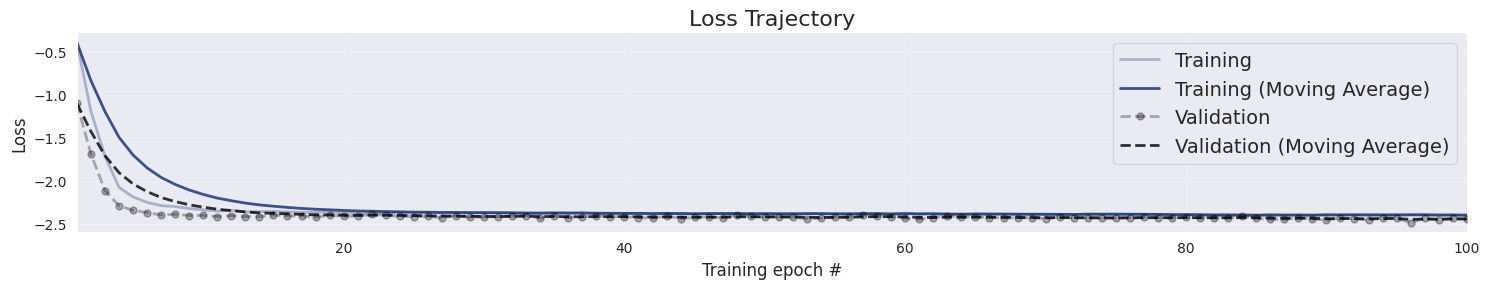

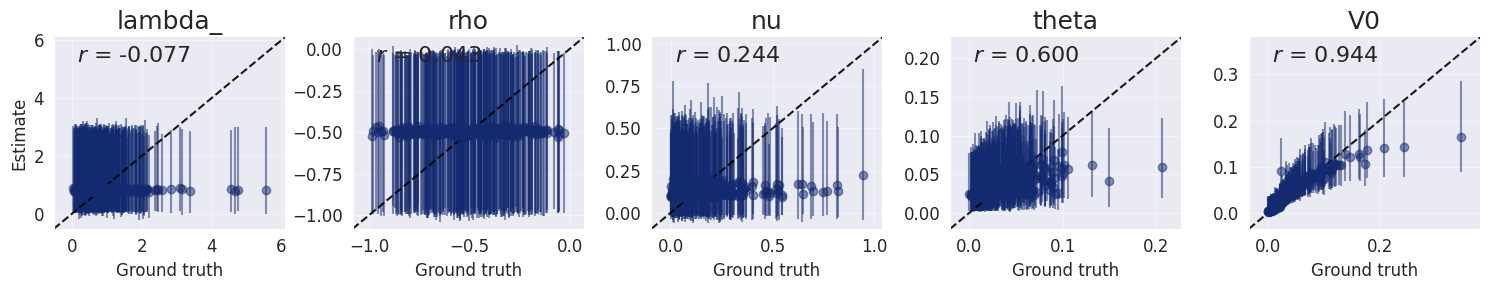

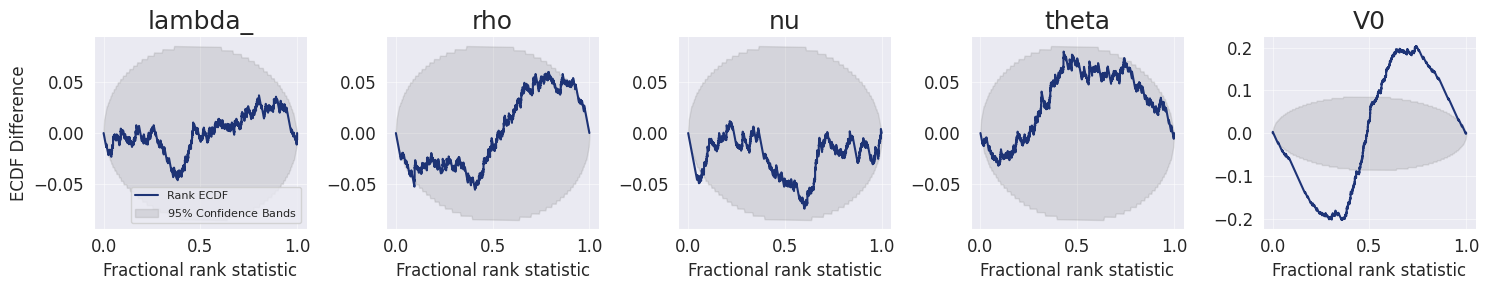

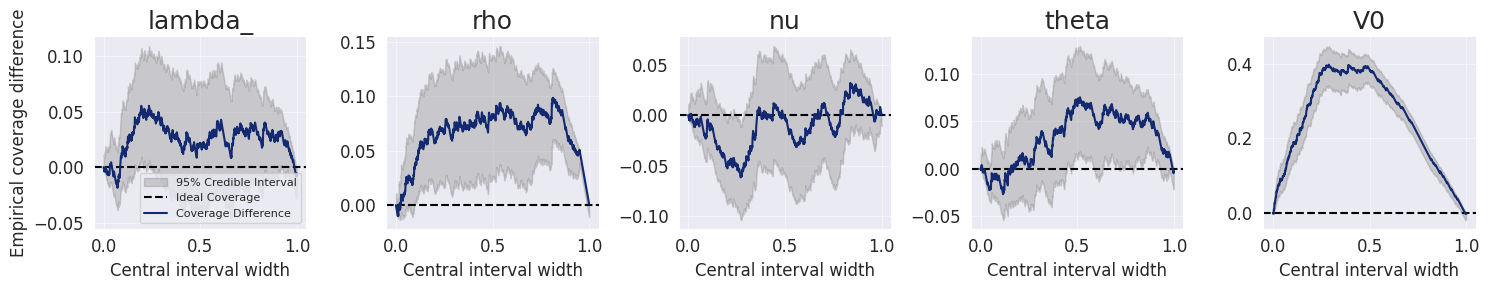

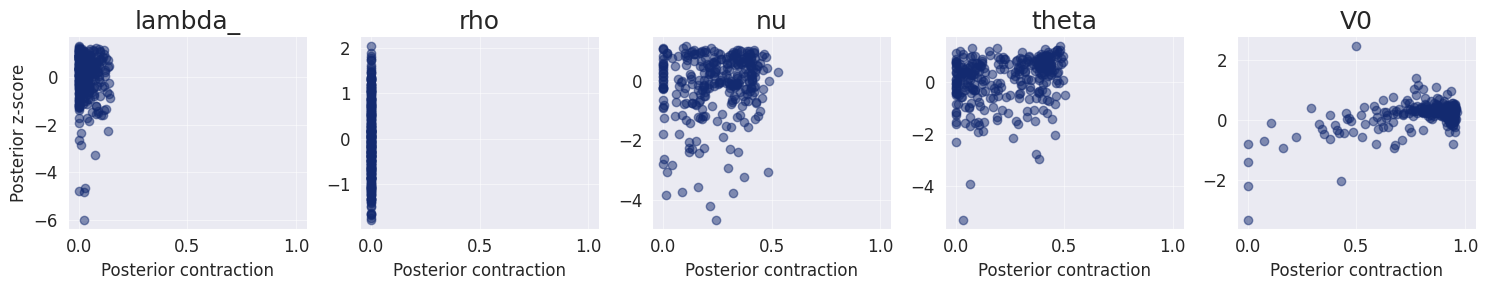

In [25]:
figures = workflow.plot_default_diagnostics(
    test_data=val_set,
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 12},
    recovery_kwargs={"figsize": (15, 3), "label_fontsize": 12},
    calibration_ecdf_kwargs={"figsize": (15, 3), "legend_fontsize": 8, "label_fontsize": 12, "difference": True},
    coverage_kwargs={"figsize": (15, 3), "legend_fontsize": 8, "label_fontsize": 12, "difference": True},
    z_score_contraction_kwargs={"figsize": (15, 3), "label_fontsize": 12}
)